# **Airbnb Data Analysis**



# Data Cleaning,Preparation and EDA

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Airbnb_Open_Data.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'Airbnb_Open_Data.csv'

In [ ]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [ ]:
df.shape

(102599, 26)

In [159]:
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='object')

In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [161]:
df.dtypes

,0
id,int64
NAME,object
host id,int64
host_identity_verified,object
host name,object
neighbourhood group,object
neighbourhood,object
lat,float64
long,float64
country,object


In [162]:
df.isnull().sum()

,0
id,0
NAME,250
host id,0
host_identity_verified,289
host name,406
neighbourhood group,29
neighbourhood,16
lat,8
long,8
country,532


In [163]:
# Drop rows where 'NAME' column has NaN values
df = df.dropna(subset=["NAME"])

In [164]:
df['NAME'].isnull().sum()

np.int64(0)

In [165]:
df.isnull().sum()

,0
id,0
NAME,0
host id,0
host_identity_verified,277
host name,400
neighbourhood group,27
neighbourhood,16
lat,8
long,8
country,527


In [166]:
#There is no neeed the Licence Columns so, drop it
df.drop('house_rules',axis = 1,inplace= True)

In [167]:
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'license'],
      dtype='object')

In [168]:
#Drop the columns that contain null values in essential fields
df = df.dropna(subset= ['host id', 'host_identity_verified', 'host name','minimum nights','instant_bookable','neighbourhood group','neighbourhood','country code','lat','long','Construction year','calculated host listings count'])

In [218]:
df['instant_bookable'].unique()

array([False, True], dtype=object)

In [234]:
df['minimum nights'].unique()

array([  10,   30,    3,   45,    2,    1,    5,    4,   90,   60,    7,
          9,   31,    6,    8,   15,   47,   81,  144,  371,  268,  189,
        340,  128,  350,  166,  110,  142,  366,   14,  200,   50,  399,
         11,  452,   13, 3455,   21,   27,   18,   20,   12,   40,  398,
         28,   65,   29,   55,  120,  365,  180,  122,   19,  240,   88,
        115,  150,  370,   16,  181,   26,   80,   25,  265,  300,   17,
         59,  185,  360,   56,   70,   39,   24,   32,  270,   22,   75,
        250,   62,   23, 1250,  364,   74,  198,  100,  500,   43,   35,
         91,  480,   53,   99,  160,  999,  186,   68,   93,   87,  183,
        299,  175,   98,  133,  354,   42,   33,   37,  225,  400,  105,
        184,  153,  134,  222,   58,  210,  275,  182,   44,  954, 5645,
       2645, 1223,  114,   85,   36,   48,  155,  307,  129,  145,   64,
        333,  119,  125,   34,  458,  825])

In [221]:
df['minimum nights'] = df['minimum nights'].astype(int)

In [222]:
df['minimum nights'].dtype

dtype('int64')

In [225]:
df['minimum nights'] = df['minimum nights'].abs()

In [226]:
df['minimum nights'].unique()

array([  10,   30,    3,   45,    2,    1,    5,    4,   90,   60,    7,
          9,   31,    6,    8,   15,   47,   81,  144,  371,  268,  189,
        340,  128,  350,  166,  110,  142,  366,   14,  200,   50,  399,
         11,  452,   13, 3455,   21,   27,   18,   20,   12,   40,  398,
         28,   65,   29,   55,  120,  365,  180,  122,   19,  240,   88,
        115,  150,  370,   16,  181,   26,   80,   25,  265,  300,   17,
         59,  185,  360,   56,   70,   39,   24,   32,  270,   22,   75,
        250,   62,   23, 1250,  364,   74,  198,  100,  500,   43,   35,
         91,  480,   53,   99,  160,  999,  186,   68,   93,   87,  183,
        299,  175,   98,  133,  354,   42,   33,   37,  225,  400,  105,
        184,  153,  134,  222,   58,  210,  275,  182,   44,  954, 5645,
       2645, 1223,  114,   85,   36,   48,  155,  307,  129,  145,   64,
        333,  119,  125,   34,  458,  825])

In [228]:
df['host name'].dtype

dtype('O')

In [229]:
df['instant_bookable'].dtype


dtype('O')

In [169]:
df.isnull().sum()

,0
id,0
NAME,0
host id,0
host_identity_verified,0
host name,0
neighbourhood group,0
neighbourhood,0
lat,0
long,0
country,444


In [170]:
df['license'].unique()

array([nan, '41662/AL'], dtype=object)

In [171]:
df = df.fillna({'last review': '0', 'reviews per month': '0','number of reviews': '0'})

In [172]:
df['last review'].unique()

array(['10/19/2021', '5/21/2022', '11/19/2018', ..., '2/24/2020',
       '9/20/2015', '4/15/2014'], dtype=object)

In [173]:
df['reviews per month'].unique()

array([0.21, 0.38, 0.1, ..., 24.49, 33.08, 10.37], dtype=object)

In [174]:
df.isnull().sum()

,0
id,0
NAME,0
host id,0
host_identity_verified,0
host name,0
neighbourhood group,0
neighbourhood,0
lat,0
long,0
country,444


In [175]:
df['country'].unique()

array(['United States', nan], dtype=object)

In [176]:
df = df.fillna({'country': 'United States'})

In [177]:
df.isnull().sum()

,0
id,0
NAME,0
host id,0
host_identity_verified,0
host name,0
neighbourhood group,0
neighbourhood,0
lat,0
long,0
country,0


In [178]:
# Remove '$' and convert 'service fee' to numeric, then fill NaN with the mean
df['service fee'] = df['service fee'].astype(str).str.replace('$', '', regex=False).astype(float)
df['service fee'] = df['service fee'].fillna(df['service fee'].mean()).astype(int)

In [179]:
df['service fee'].unique()

array([193,  28,  41, 115, 212, 204,  58,  64, 121, 116,  30, 125,  38,
       222, 219, 113,  74, 171,  12,  88, 165, 129, 207,  17,  63, 147,
        48, 213, 211, 182, 117,  39,  25,  10, 118, 168, 106,  13, 152,
       105,  90, 186,  66, 225,  19, 227,  32, 189, 101,  23,  77, 190,
        75, 231, 133,  35,  82, 120,  21, 145,  65,  26,  89, 218, 104,
        44,  79, 163,  22,  37,  11, 131, 102, 240, 119, 215, 191,  16,
        94, 233, 206, 109, 157,  15, 229, 179,  85, 136, 170, 201, 123,
        36, 180, 238,  14, 198, 122, 208, 140, 228,  20, 110,  98, 234,
       151, 172, 107, 138, 194, 139,  31, 156, 124, 203, 175, 162, 187,
        93,  51, 143, 239, 184, 161, 149, 181,  50, 144,  33,  45,  46,
       209,  55,  87,  73, 128, 210, 166,  54,  43,  18, 167, 236, 185,
        83,  69, 111, 183, 142, 100, 223,  71, 169,  95, 126,  29, 195,
        76, 220,  40,  24,  49, 232,  72, 135, 205, 221, 153,  27,  52,
        92, 137,  86, 197, 164, 108, 158, 127, 176,  62, 132, 14

In [180]:
df['price'] = df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
df['price'] = df['price'].fillna(df['service fee'].mean()).astype(int)

In [181]:
df['price'].unique()

array([966, 142, 204, ..., 905, 309, 770])

In [182]:
df['review rate number'] = df['review rate number'].fillna(df['review rate number'].mean()).astype(int)

In [183]:
df['review rate number'].unique()

array([4, 3, 5, 2, 1])

In [184]:
df.isnull().sum()

,0
id,0
NAME,0
host id,0
host_identity_verified,0
host name,0
neighbourhood group,0
neighbourhood,0
lat,0
long,0
country,0


In [185]:
df.shape

(100640, 25)

In [186]:
df['license'].unique()

array([nan, '41662/AL'], dtype=object)

In [187]:
df['license'] = df['license'].fillna("No License")

In [188]:
df.isnull().sum()

,0
id,0
NAME,0
host id,0
host_identity_verified,0
host name,0
neighbourhood group,0
neighbourhood,0
lat,0
long,0
country,0


In [189]:
df['availability 365'].unique()

array([ 2.860e+02,  2.280e+02,  2.890e+02,  3.740e+02,  2.190e+02,
        1.800e+02,  3.750e+02,  1.000e+00,  1.630e+02,  4.700e+01,
        6.800e+01,  1.000e+02,  7.600e+01,  4.160e+02,  2.940e+02,
        2.140e+02,  3.560e+02,  3.540e+02,  3.300e+01,  8.600e+01,
        1.520e+02,        nan,  8.300e+01,  2.580e+02,  4.000e+02,
        3.400e+01,  2.030e+02,  3.500e+01,  4.100e+02,  3.880e+02,
        1.300e+01,  6.200e+01,  3.340e+02,  3.370e+02,  1.660e+02,
        1.800e+01,  1.300e+02,  4.300e+01,  3.730e+02,  1.900e+02,
        3.350e+02,  5.200e+01,  7.000e+01,  3.200e+02,  1.900e+01,
        2.930e+02,  5.800e+01,  2.400e+02,  9.600e+01,  3.000e+02,
        4.250e+02,  3.320e+02,  3.610e+02,  3.410e+02,  3.530e+02,
        2.130e+02,  1.370e+02,  3.360e+02,  2.300e+01,  3.950e+02,
        7.800e+01,  1.880e+02,  3.380e+02,  6.600e+01,  3.220e+02,
        8.000e+01,  1.460e+02,  3.820e+02,  0.000e+00,  3.190e+02,
        5.000e+01,  1.180e+02,  3.500e+02,  8.500e+01,  1.450e

In [190]:
df['availability 365'].mean()

np.float64(141.04836039414369)

In [191]:
df['availability 365'] = pd.to_numeric(df['availability 365'], errors='coerce')
df['availability 365'] = df['availability 365'].abs()
mean_availability = df['availability 365'].mean()
df['availability 365'] = df['availability 365'].fillna(mean_availability)
df['availability 365'] = df['availability 365'].astype(int)

In [192]:
df['availability 365'].unique()

array([ 286,  228,  289,  374,  219,  180,  375,    1,  163,   47,   68,
        100,   76,  416,  294,  214,  356,  354,   33,   86,  152,  141,
         83,  258,  400,   34,  203,   35,  410,  388,   13,   62,  334,
        337,  166,   18,  130,   43,  373,  190,  335,   52,   70,  320,
         19,  293,   58,  240,   96,  300,  425,  332,  361,  341,  353,
        213,  137,  336,   23,  395,   78,  188,  338,   66,  322,   80,
        146,  382,    0,  319,   50,  118,  350,   85,  145,  267,  407,
         16,  351,  397,  276,  398,  135,  315,  105,   87,  189,   81,
         42,  177,  245,  386,  247,  394,  179,  312,  419,  256,  380,
        270,   45,  176,  379,  210,  264,  402,   53,  252,   82,    5,
        362,  238,  318,  280,  140,  107,  131,  117,   84,  291,  132,
        327,  325,  331,  378,  283,  114,   77,  376,  211,  112,  296,
        193,  248,  231,  399,  182,  381,  253,  191,  414,  159,  389,
          9,  345,  186,  187,  268,  209,   88,  4

In [193]:
df['availability 365'].dtype

dtype('int64')

In [194]:
df.isnull().sum()

,0
id,0
NAME,0
host id,0
host_identity_verified,0
host name,0
neighbourhood group,0
neighbourhood,0
lat,0
long,0
country,0


In [195]:
df['number of reviews']

,number of reviews
0,9.0
1,45.0
4,9.0
5,74.0
7,49.0
...,...
102594,0.0
102595,1.0
102596,0.0
102597,5.0


In [196]:
df['calculated host listings count'].unique()

array([  6.,   2.,   1.,   4.,   3.,   5.,   7.,  28.,  11.,   8.,   9.,
        52.,  18.,  15.,  19.,  10.,  39.,  13.,  26.,  29.,  12.,  21.,
        96.,  14.,  34.,  43., 121.,  37.,  49.,  31.,  91.,  16.,  87.,
        33.,  23.,  50.,  20.,  25., 232.,  17.,  47., 103.,  65.,  30.,
        27., 327.,  32.,  53., 208., 171.,  44.,  48., 108.,  51., 161.,
       152.,  83.,  24.,  22., 126.,  54.,  66.,  59.,  62., 102., 186.,
       125.,  55.,  63.,  67.,  58.,  56.,  80.,  46., 218.,  86., 332.])

In [197]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100640 entries, 0 to 102598
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              100640 non-null  int64  
 1   NAME                            100640 non-null  object 
 2   host id                         100640 non-null  int64  
 3   host_identity_verified          100640 non-null  object 
 4   host name                       100640 non-null  object 
 5   neighbourhood group             100640 non-null  object 
 6   neighbourhood                   100640 non-null  object 
 7   lat                             100640 non-null  float64
 8   long                            100640 non-null  float64
 9   country                         100640 non-null  object 
 10  country code                    100640 non-null  object 
 11  instant_bookable                100640 non-null  object 
 12  cancellation_policy  

In [198]:
df.head(10)

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,966,193,10.0,9.0,10/19/2021,0.21,4,6.0,286,No License
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,142,28,30.0,45.0,5/21/2022,0.38,4,2.0,228,No License
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,204,41,10.0,9.0,11/19/2018,0.1,3,1.0,289,No License
5,1004098,Large Cozy 1 BR Apartment In Midtown East,45498551794,verified,Michelle,Manhattan,Murray Hill,40.74767,-73.97500,United States,...,577,115,3.0,74.0,6/22/2019,0.59,3,1.0,374,No License
7,1005202,BlissArtsSpace!,90821839709,unconfirmed,Emma,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,United States,...,1060,212,45.0,49.0,10/5/2017,0.4,5,1.0,219,No License
8,1005754,Large Furnished Room Near B'way,79384379533,verified,Evelyn,Manhattan,Hell's Kitchen,40.76489,-73.98493,United States,...,1018,204,2.0,430.0,6/24/2019,3.47,3,1.0,180,No License
9,1006307,Cozy Clean Guest Room - Family Apt,75527839483,unconfirmed,Carl,Manhattan,Upper West Side,40.80178,-73.96723,United States,...,291,58,2.0,118.0,7/21/2017,0.99,5,1.0,375,No License
10,1006859,Cute & Cozy Lower East Side 1 bdrm,1280143094,verified,Miranda,Manhattan,Chinatown,40.71344,-73.99037,United States,...,319,64,1.0,160.0,6/9/2019,1.33,3,4.0,1,No License
11,1007411,Beautiful 1br on Upper West Side,18824631834,verified,Alan,Manhattan,Upper West Side,40.80316,-73.96545,United States,...,606,121,5.0,53.0,6/22/2019,0.43,4,1.0,163,No License
13,1008516,"Lovely Room 1, Garden, Best Area, Legal rental",26802410424,verified,Darcy,brookln,South Slope,40.66829,-73.98779,United States,...,580,116,4.0,167.0,6/24/2019,1.34,4,3.0,47,No License


In [199]:
df.to_csv('Airbnb_cleaned_data.csv', index=False)

In [200]:
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'license'],
      dtype='object')

#Anlysis of the DataSet

#Univariate analysis


## **Price Distribution plot**


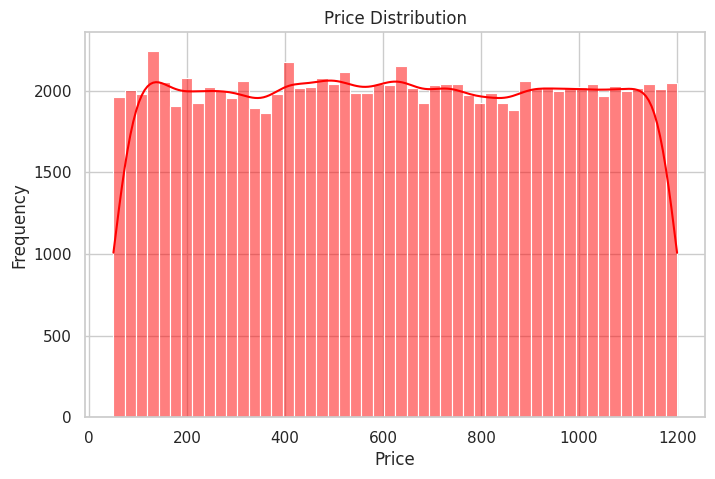

In [201]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50, kde=True,color='red')
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Price Distribution")
plt.show()

## **Service Fee Distribution using hist plot**

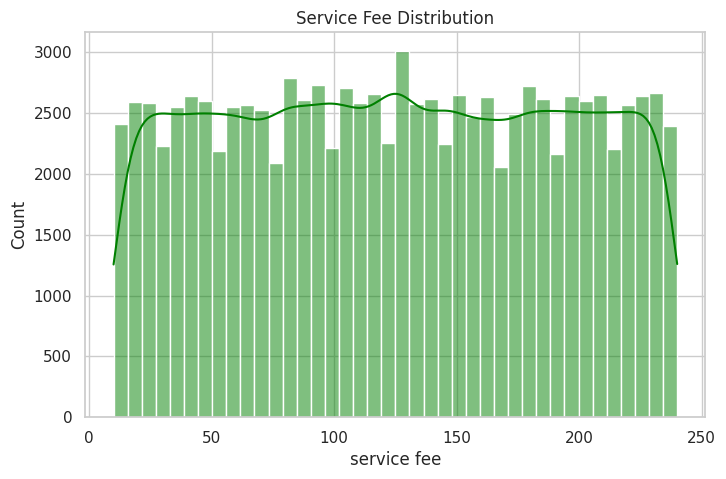

In [202]:
plt.figure(figsize=(8,5))
sns.histplot(df['service fee'], bins=40, kde=True,color='green')
plt.title("Service Fee Distribution")
plt.show()

## **Minimum Night Distribution using hist plot**

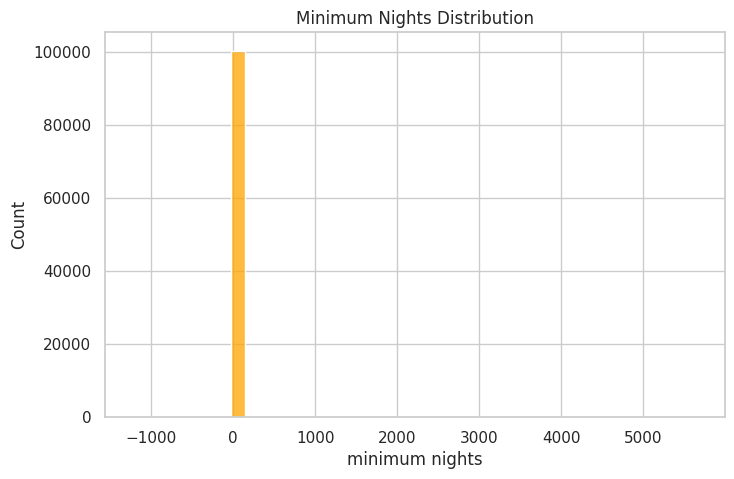

In [203]:
plt.figure(figsize=(8,5))
sns.histplot(df['minimum nights'], bins=40, color = 'orange')
plt.title("Minimum Nights Distribution")
plt.show()

## **Distribution of Number of Reviews**

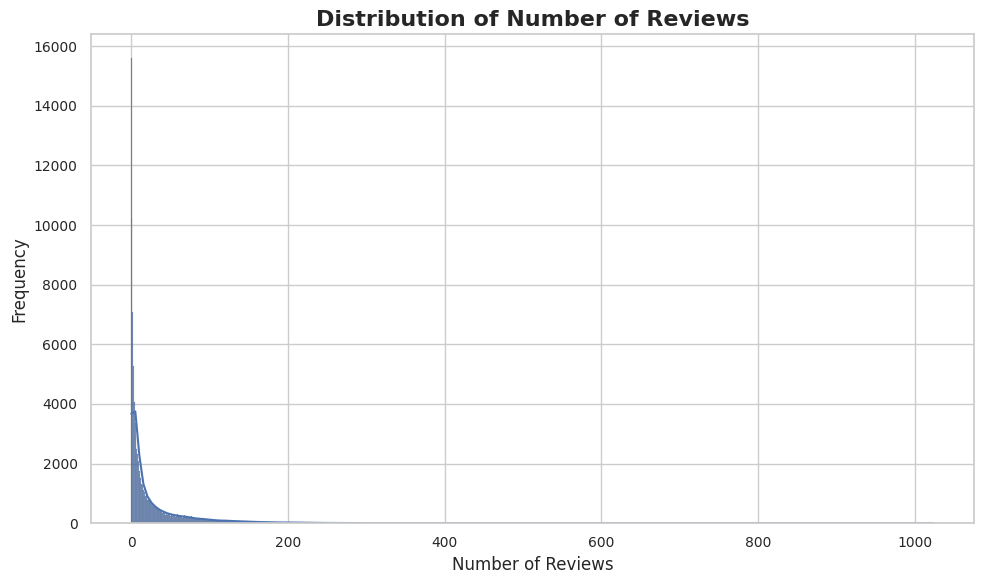

In [204]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))
sns.histplot(data=df,x='number of reviews',bins=40,kde=True,edgecolor='black',alpha=0.7)
plt.title("Distribution of Number of Reviews", fontsize=16, fontweight='bold')
plt.xlabel("Number of Reviews", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

## **Price Distribution & Outliers using Box plot**

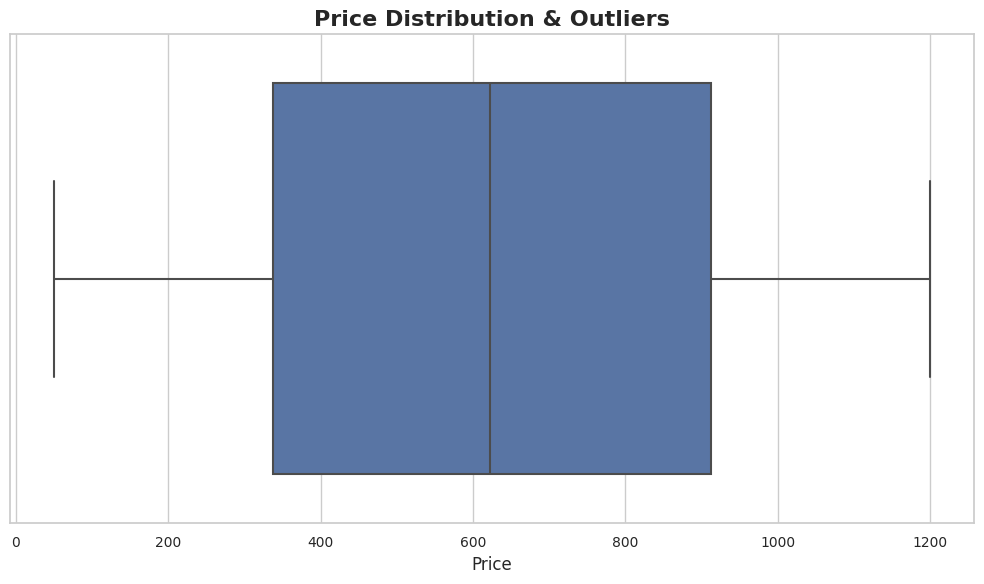

In [205]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))
sns.boxplot(x=df['price'],linewidth=1.5,fliersize=5)
plt.title("Price Distribution & Outliers", fontsize=16, fontweight='bold')
plt.xlabel("Price", fontsize=12)
plt.xticks(fontsize=10)
plt.tight_layout()
plt.show()

## **Distribution of Availability**

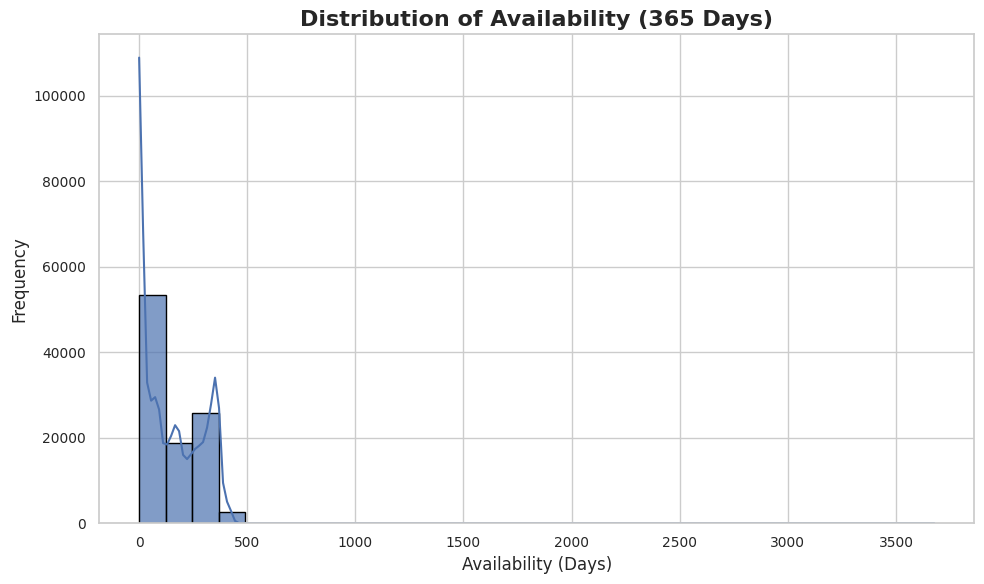

In [206]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))
sns.histplot(data=df,x='availability 365',bins=30,kde=True,edgecolor='black',alpha=0.7)
plt.title("Distribution of Availability (365 Days)", fontsize=16, fontweight='bold')
plt.xlabel("Availability (Days)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Bivariate Analysis

## **Price vs Room Type**

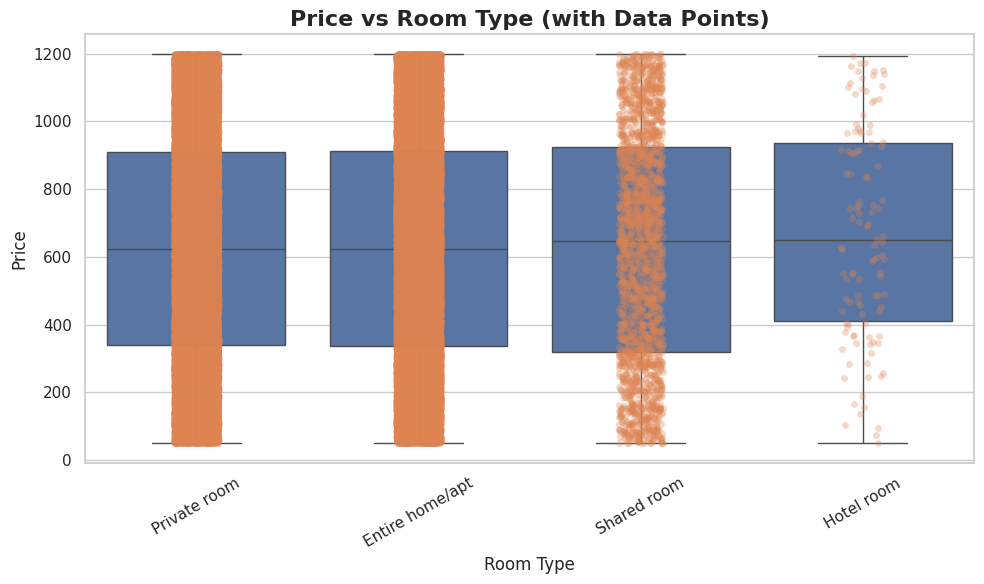

In [207]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='room type', y='price')
sns.stripplot(data=df, x='room type', y='price', alpha=0.3)
plt.title("Price vs Room Type (with Data Points)", fontsize=16, fontweight='bold')
plt.xlabel("Room Type")
plt.ylabel("Price")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## **Price vs Neighbourhood Group**

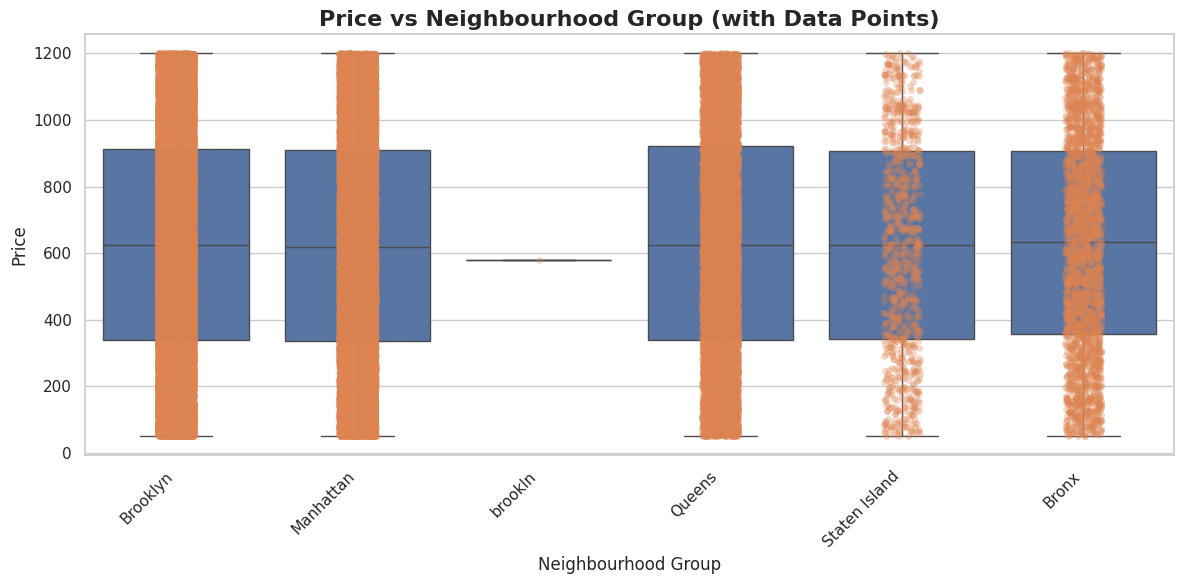

In [208]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='neighbourhood group', y='price')
sns.stripplot(data=df, x='neighbourhood group', y='price', alpha=0.3)
plt.title("Price vs Neighbourhood Group (with Data Points)", fontsize=16, fontweight='bold')
plt.xlabel("Neighbourhood Group")
plt.ylabel("Price")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## **Price vs Review Rating**



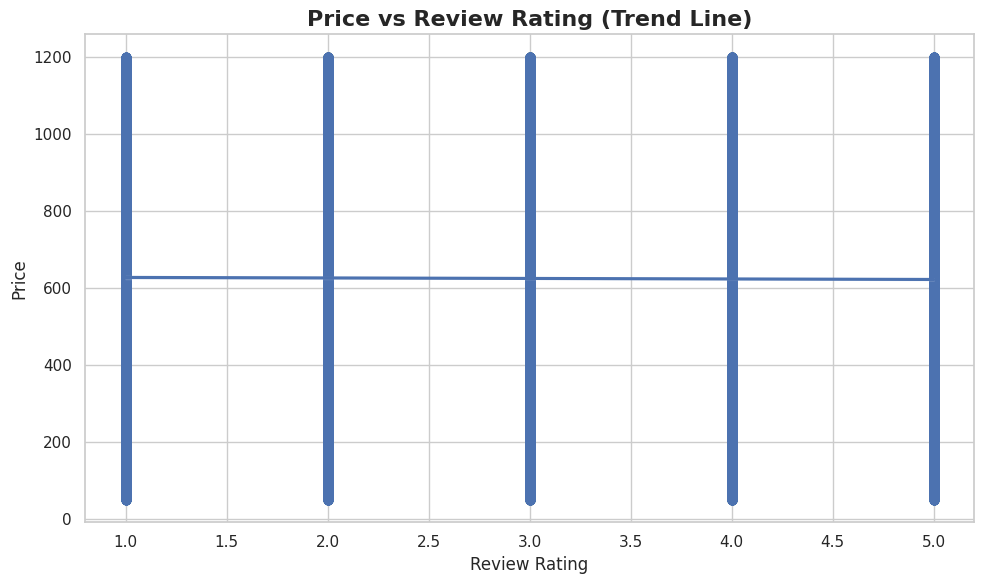

In [209]:
plt.figure(figsize=(10,6))
sns.regplot(data=df,x='review rate number',y='price',scatter_kws={'alpha':0.5})
plt.title("Price vs Review Rating (Trend Line)", fontsize=16, fontweight='bold')
plt.xlabel("Review Rating")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

## **Reviews vs Reviews per Month**

In [210]:
df['number of reviews'].dtype

dtype('O')

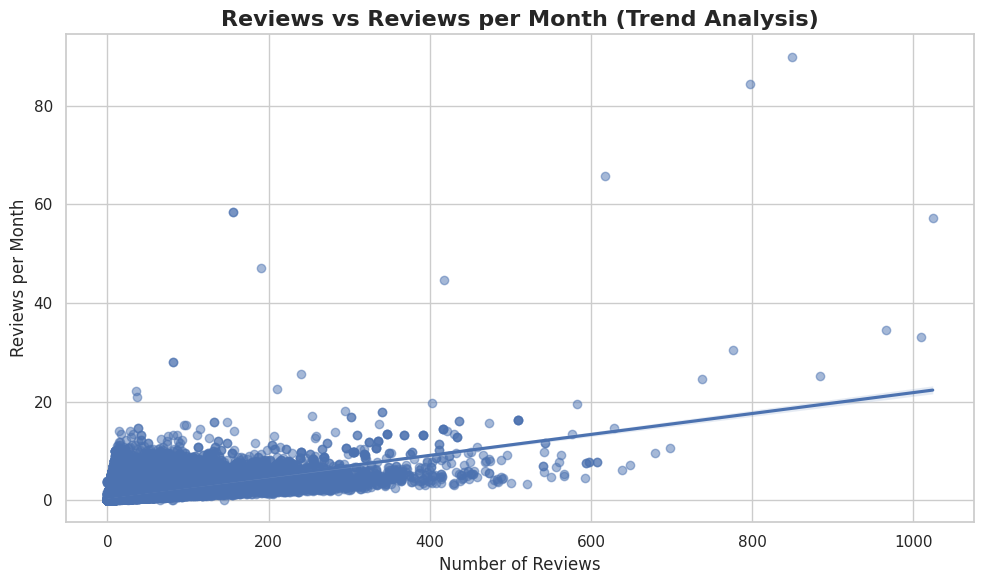

In [211]:
df['number of reviews'] = pd.to_numeric(df['number of reviews'], errors='coerce')
df['reviews per month'] = pd.to_numeric(df['reviews per month'], errors='coerce')
plt.figure(figsize=(10,6))
sns.regplot(data=df,x='number of reviews',y='reviews per month',scatter_kws={'alpha':0.5})
plt.title("Reviews vs Reviews per Month (Trend Analysis)", fontsize=16, fontweight='bold')
plt.xlabel("Number of Reviews")
plt.ylabel("Reviews per Month")
plt.tight_layout()
plt.show()

## **Price Distribution by Instant Bookable**

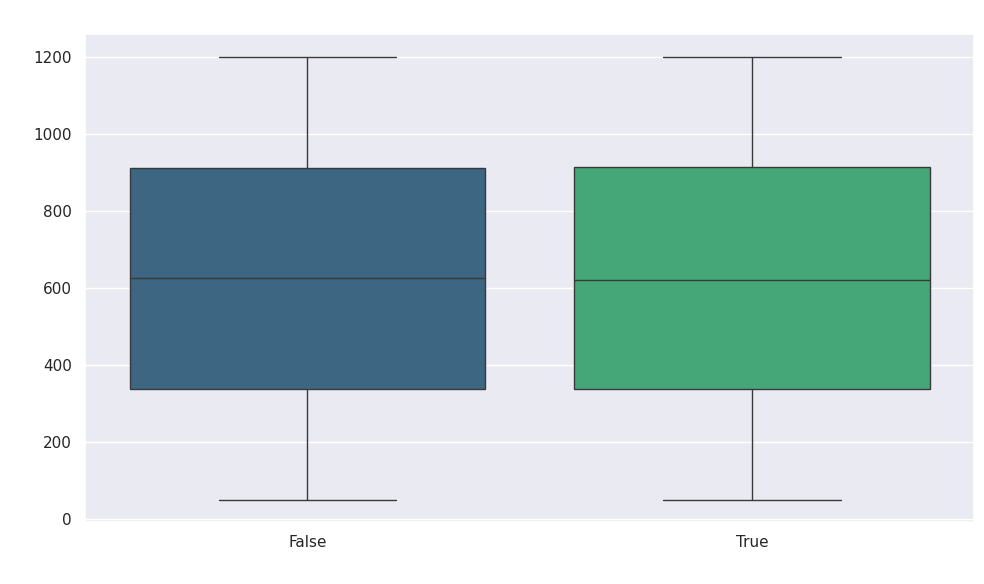

In [212]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='instant_bookable',y='price',palette='viridis')
plt.title("Price Distribution by Instant Bookable", fontsize=16, fontweight='bold', color='white')
plt.xlabel("Instant Bookable", color='white')
plt.ylabel("Price", color='white')
plt.tight_layout()
plt.show()

#Multivariate Analysis

## **Price by Location & Room Type**

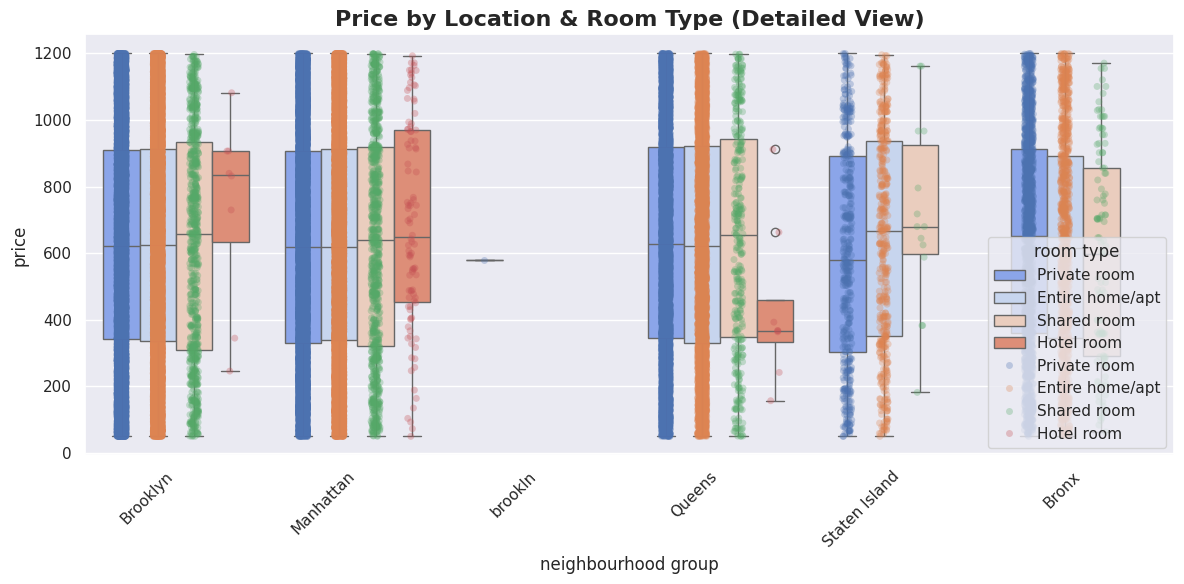

In [213]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df,x='neighbourhood group',y='price',hue='room type',palette='coolwarm')
sns.stripplot(data=df,x='neighbourhood group',y='price',hue='room type',dodge=True,alpha=0.3,linewidth=0)
plt.title("Price by Location & Room Type (Detailed View)", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## **Reviews vs Price vs Rating vs Availability**

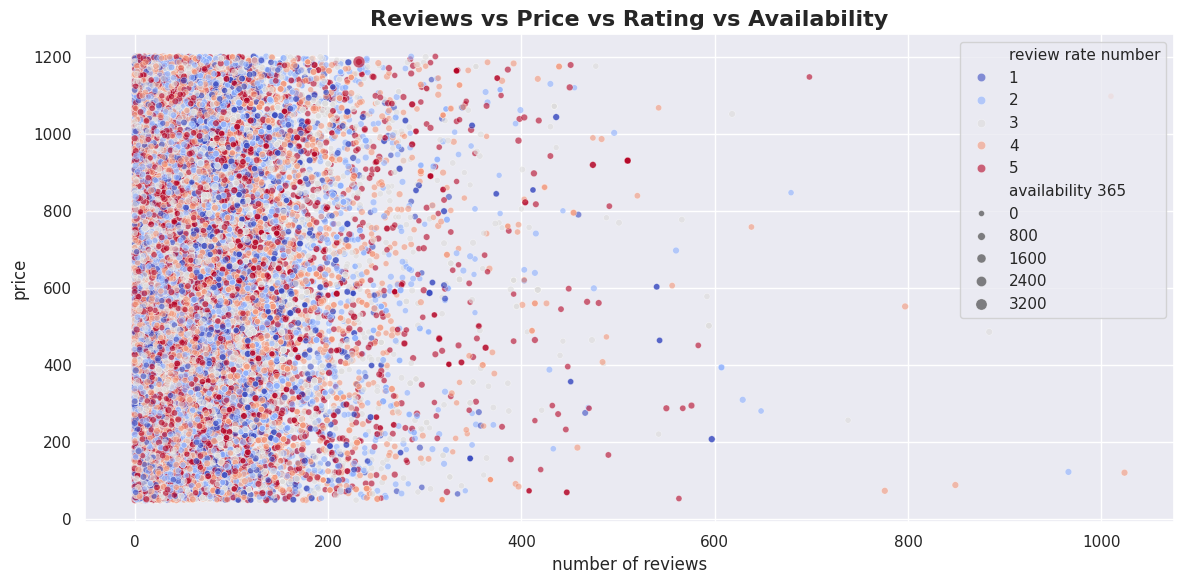

In [214]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df,x='number of reviews',y='price',hue='review rate number',size='availability 365',palette='coolwarm',alpha=0.6)
plt.title("Reviews vs Price vs Rating vs Availability", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## **Availability vs Reviews per Month vs Price**

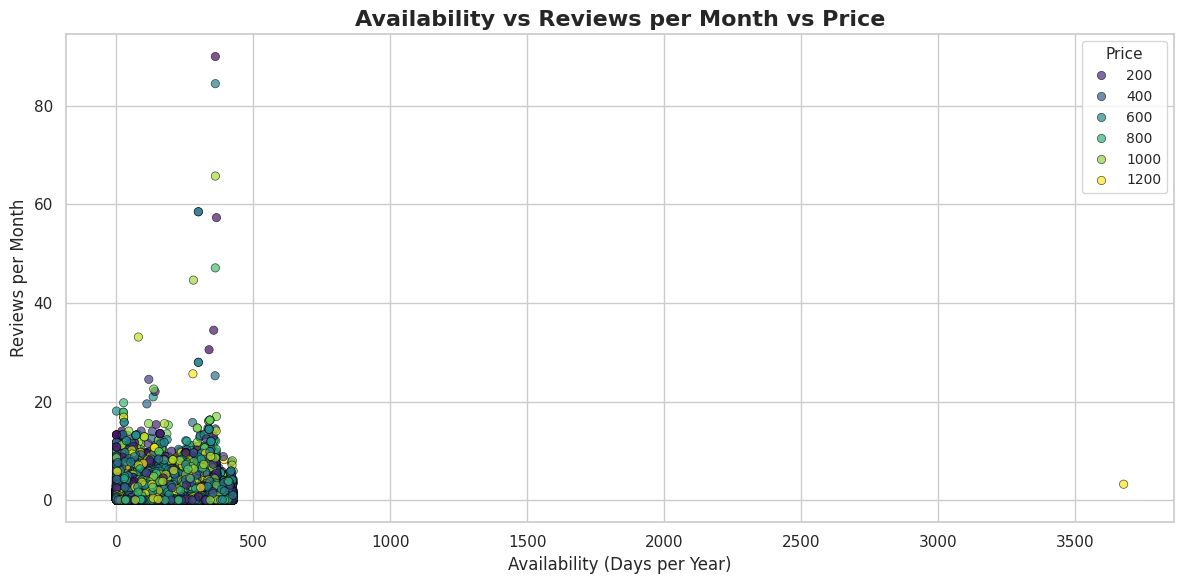

In [215]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12,6))
sns.scatterplot(data=df,x='availability 365',y='reviews per month',hue='price',palette='viridis',alpha=0.7,edgecolor='black')
plt.title("Availability vs Reviews per Month vs Price", fontsize=16, fontweight='bold')
plt.xlabel("Availability (Days per Year)", fontsize=12)
plt.ylabel("Reviews per Month", fontsize=12)
plt.legend(title="Price", fontsize=10, title_fontsize=11)
plt.tight_layout()
plt.show()

## **Correlation Heatmap**

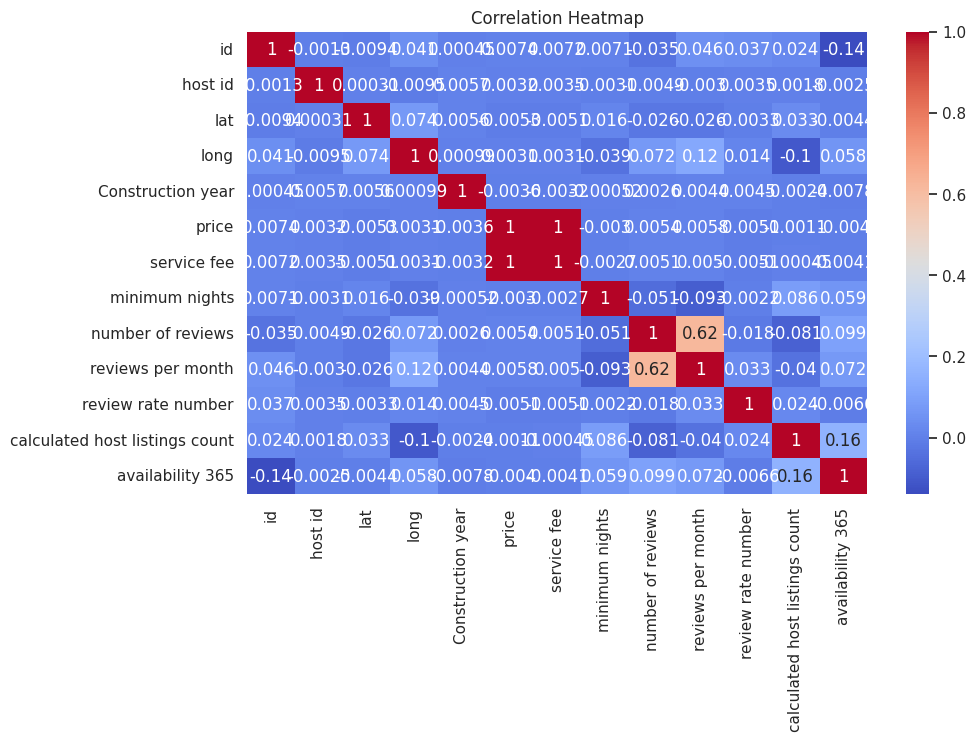

In [216]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## **Pairplot with Review Rating Influence**

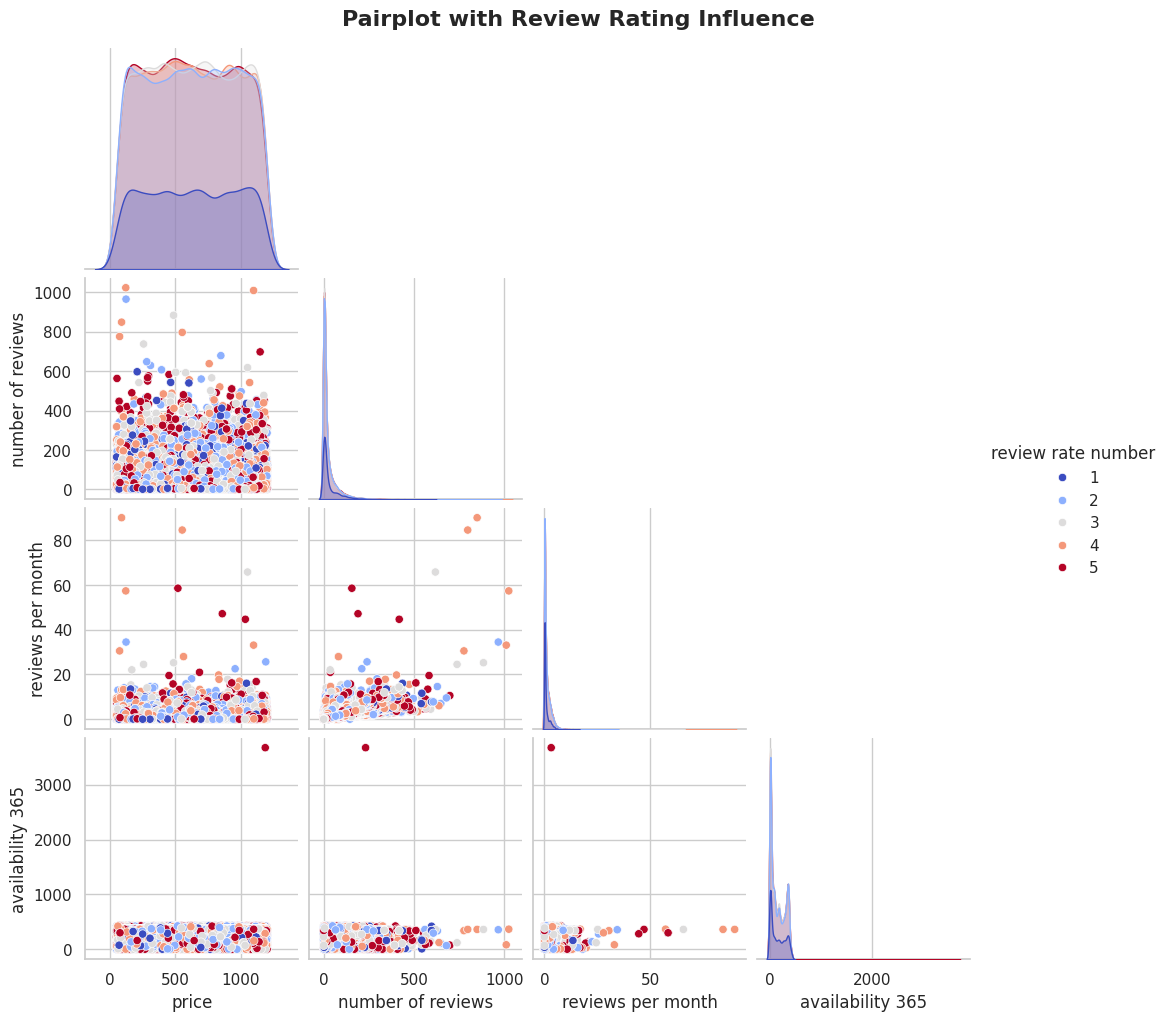

In [217]:
sns.pairplot(df[['price','number of reviews','reviews per month','review rate number','availability 365']],
hue='review rate number',palette='coolwarm',diag_kind='kde',corner=True)
plt.suptitle("Pairplot with Review Rating Influence",fontsize=16, fontweight='bold', y=1.02)
plt.show()
